In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
rel = pd.read_csv(r"C:\Users\archa\Videos\Project\AlgoTradingProject\data\reliance.csv")
tcs = pd.read_csv(r"C:\Users\archa\Videos\Project\AlgoTradingProject\data\tcs.csv")
hdfc = pd.read_csv(r"C:\Users\archa\Videos\Project\AlgoTradingProject\data\hdfcbank.csv")
rel.head()
tcs.head()
hdfc.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2025-10-03 00:00:00+05:30,952.000000,966.750000,952.000000,965.150024,26658296,0.0,0.0
1,2025-10-06 00:00:00+05:30,971.900024,977.400024,962.000000,973.450012,18542683,0.0,0.0
2,2025-10-07 00:00:00+05:30,974.000000,989.849976,971.000000,982.500000,25535736,0.0,0.0
3,2025-10-08 00:00:00+05:30,976.000000,985.900024,974.549988,978.700012,15939710,0.0,0.0
4,2025-10-09 00:00:00+05:30,974.500000,979.000000,970.150024,977.099976,15370950,0.0,0.0


In [3]:
rel['Date'] = pd.to_datetime(rel['Date'])
tcs['Date'] = pd.to_datetime(tcs['Date'])
hdfc['Date'] = pd.to_datetime(hdfc['Date'])

rel = rel.sort_values('Date')
tcs = tcs.sort_values('Date')
hdfc = hdfc.sort_values('Date')

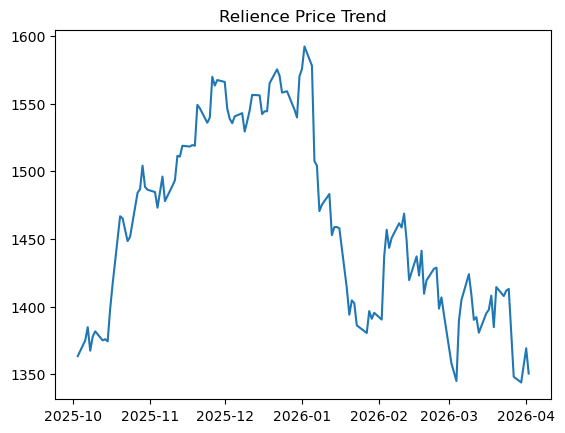

In [4]:
# Price Graph
plt.figure()
plt.plot(rel['Date'],rel['Close'])
plt.title("Relience Price Trend")
plt.show()

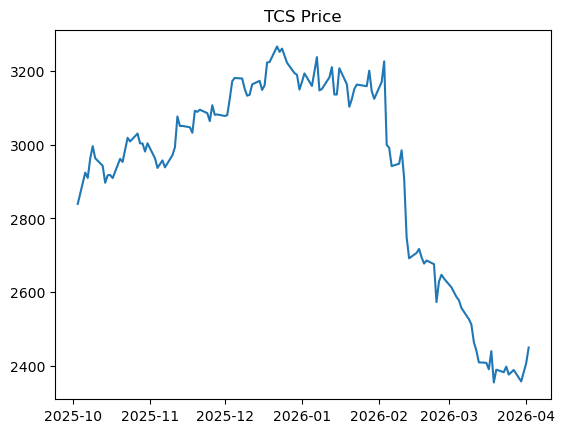

In [5]:
plt.figure
plt.plot(tcs['Date'],tcs['Close'])
plt.title("TCS Price")
plt.show()

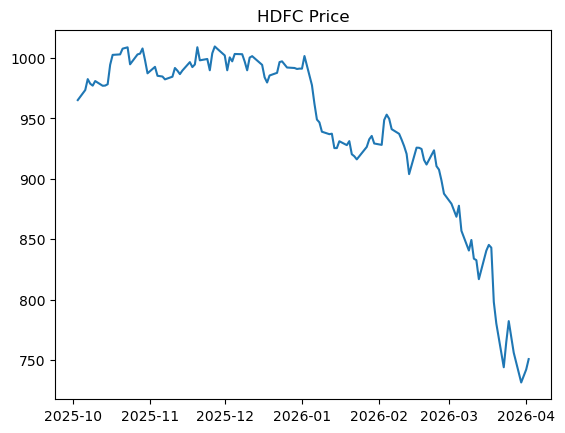

In [6]:
plt.figure
plt.plot(hdfc['Date'], hdfc['Close'])
plt.title("HDFC Price")
plt.show()

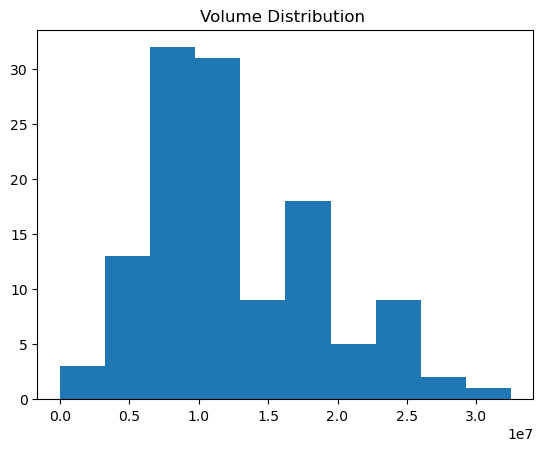

In [7]:
# Volume Graph
plt.figure()
plt.hist(rel['Volume'])
plt.title("Volume Distribution ")
plt.show()

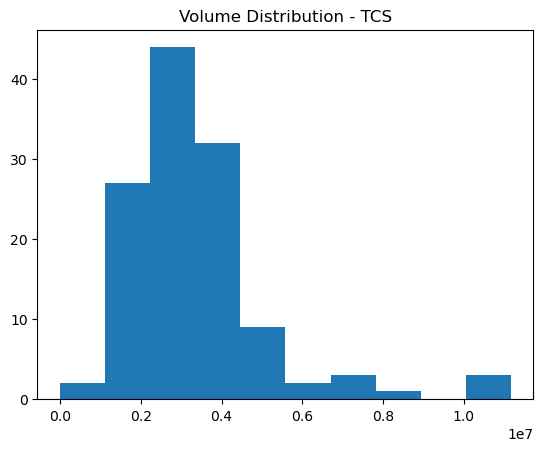

In [8]:
plt.figure()
plt.hist(tcs['Volume'])
plt.title("Volume Distribution - TCS")
plt.show()

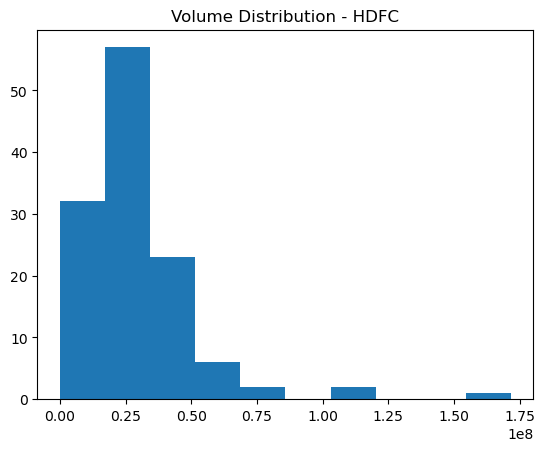

In [9]:
plt.figure()
plt.hist(hdfc['Volume'])
plt.title("Volume Distribution - HDFC")
plt.show()

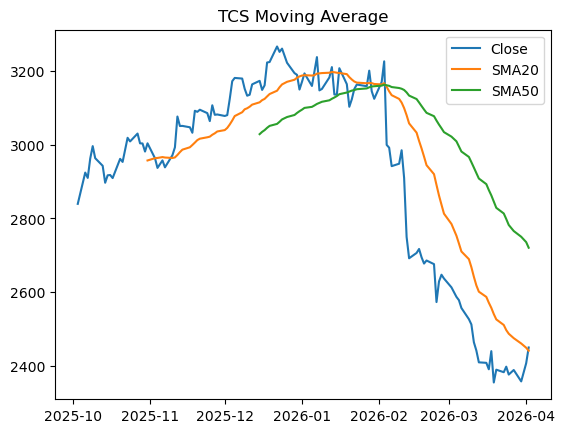

In [10]:
tcs['SMA20'] = tcs['Close'].rolling(20).mean()
tcs['SMA50'] = tcs['Close'].rolling(50).mean()

plt.figure()
plt.plot(tcs['Date'], tcs['Close'], label="Close")
plt.plot(tcs['Date'], tcs['SMA20'], label="SMA20")
plt.plot(tcs['Date'], tcs['SMA50'], label="SMA50")
plt.legend()
plt.title("TCS Moving Average")
plt.show()

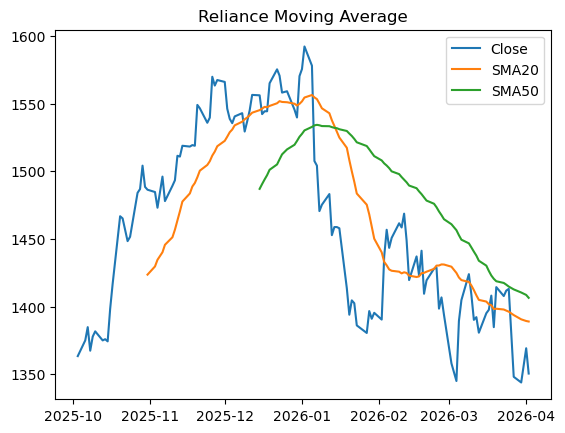

In [11]:
rel['SMA20'] = rel['Close'].rolling(20).mean()
rel['SMA50'] = rel['Close'].rolling(50).mean()

plt.figure()
plt.plot(rel['Date'], rel['Close'], label="Close")
plt.plot(rel['Date'], rel['SMA20'], label="SMA20")
plt.plot(rel['Date'], rel['SMA50'], label="SMA50")
plt.legend()
plt.title("Reliance Moving Average")
plt.show()

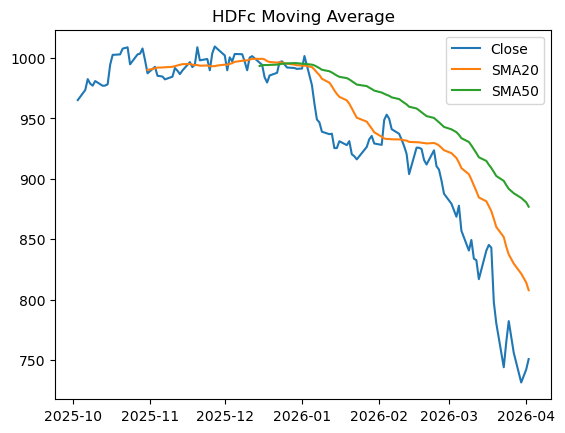

In [12]:
hdfc['SMA20'] = hdfc['Close'].rolling(20).mean()
hdfc['SMA50'] = hdfc['Close'].rolling(50).mean()

plt.figure()
plt.plot(hdfc['Date'], hdfc['Close'], label="Close")
plt.plot(hdfc['Date'], hdfc['SMA20'], label="SMA20")
plt.plot(hdfc['Date'], hdfc['SMA50'], label="SMA50")
plt.legend()
plt.title("HDFc Moving Average")
plt.show()

In [13]:
def calculate_rsi(df, window=14):
    delta = df['Close'].diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))

    return df

In [14]:
rel = calculate_rsi(rel)
tcs = calculate_rsi(tcs)
hdfc = calculate_rsi(hdfc)

In [15]:
def generate_signal(df):
    df['Signal'] = 0

    for i in range(1, len(df)):
        # BUY
        if df.loc[i, 'RSI'] < 30 and df.loc[i, 'SMA20'] > df.loc[i, 'SMA50']:
            df.loc[i, 'Signal'] = 1

        # SELL
        elif df.loc[i, 'RSI'] > 70 or df.loc[i, 'SMA20'] < df.loc[i, 'SMA50']:
            df.loc[i, 'Signal'] = -1

    return df

In [16]:
rel = generate_signal(rel)
tcs = generate_signal(tcs)
hdfc = generate_signal(hdfc)

In [17]:
def backtest(df):
    capital = 100000   # starting money
    position = 0       # stock quantity

    for i in range(len(df)):
        # BUY
        if df['Signal'][i] == 1 and position == 0:
            position = capital / df['Close'][i]
            capital = 0

        # SELL
        elif df['Signal'][i] == -1 and position > 0:
            capital = position * df['Close'][i]
            position = 0

    # final value
    final_value = capital if position == 0 else position * df['Close'].iloc[-1]

    return final_value

In [18]:
rel_profit = backtest(rel)
tcs_profit = backtest(tcs)
hdfc_profit = backtest(hdfc)

print("Reliance Final Value:", rel_profit)
print("TCS Final Value:", tcs_profit)
print("HDFC Final Value:", hdfc_profit)

Reliance Final Value: 98354.91483636636
TCS Final Value: 100000
HDFC Final Value: 100000


In [19]:
rel['Return'] = rel['Close'].pct_change()
rel['SMA_ratio'] = rel['SMA20'] / rel['SMA50']
rel['Volume_change'] = rel['Volume'].pct_change()

In [20]:
rel['Target'] = (rel['Close'].shift(-1) > rel['Close']).astype(int)

In [21]:
import numpy as np

rel.replace([np.inf, -np.inf], np.nan, inplace=True)
rel = rel.dropna()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X = rel[['RSI', 'SMA_ratio', 'Volume_change']]
y = rel['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.5333333333333333


In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.86      0.63         7
           1       0.67      0.25      0.36         8

    accuracy                           0.53        15
   macro avg       0.58      0.55      0.50        15
weighted avg       0.59      0.53      0.49        15

[[6 1]
 [6 2]]


In [4]:
import gspread
from oauth2client.service_account import ServiceAccountCredentials

scope = ["https://spreadsheets.google.com/feeds",
         "https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name(
    "../credentials.json", scope)   

client = gspread.authorize(creds)

sheet = client.open("AlgoTradingLogs").sheet1

SpreadsheetNotFound: <Response [200]>

In [ ]:
import sys
print(sys.executable)

gspread installed successfully


In [ ]:
import sys
!{sys.executable} -m pip install gspread oauth2client

c:\Users\archa\anaconda3\python.exe


In [ ]:

import gspread
print("gspread installed successfully")

In [ ]:
sheet = client.open("AlgoTradingLogs").sheet1
print("Connected")

Connected ✅
